In [14]:
from sklearn import datasets
from sklearn import model_selection as skms
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import neighbors # Import neighbors
from sklearn import linear_model # Import linear_model
from sklearn import svm # Import svm
from sklearn import tree # Import tree
%matplotlib inline

In [15]:
import pandas as pd
student_df = pd.read_csv('studenti2.csv')
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt  = student_df['G3']

In [16]:
student_tts = skms.train_test_split(student_ftrs, student_tgt)

(student_train_ftrs, student_test_ftrs,
 student_train_tgt,  student_test_tgt) = student_tts

In [17]:
old_school = [linear_model.LinearRegression(),
              neighbors.KNeighborsRegressor(n_neighbors=3),
              neighbors.KNeighborsRegressor(n_neighbors=10)]

In [18]:
# L1, L2 penalized (abs, sqr) C=1.0 for both
penalized_lr = [linear_model.Lasso(),
                linear_model.Ridge()]

# defaults are epsilon=.1 and nu=.5, respectively
svrs = [svm.SVR(), svm.NuSVR()]

dtrees = [tree.DecisionTreeRegressor(max_depth=md) for md in [1, 3, 5, 10]]

reg_models = old_school + penalized_lr + svrs + dtrees

In [19]:
def rms_error(actual, predicted):
    ' root-mean-squared-error function '
    # lesser values are better (a<b ... a better)
    mse = metrics.mean_squared_error(actual, predicted)
    return np.sqrt(mse)
rms_scorer = metrics.make_scorer(rms_error)

In [20]:
from sklearn import preprocessing as skpre # Import preprocessing as skpre
from sklearn import pipeline # Import pipeline

def get_model_name(model):
    return type(model).__name__

scaler = skpre.StandardScaler()

scores = {}
for model in reg_models:
    pipe = pipeline.make_pipeline(scaler, model)
    preds = skms.cross_val_predict(pipe,
                                   student_ftrs, student_tgt,
                                   cv=10)
    key = (get_model_name(model) +
           str(model.get_params().get('max_depth', "")) +
           str(model.get_params().get('n_neighbors', "")))
    scores[key] = rms_error(student_tgt, preds)

df = pd.DataFrame.from_dict(scores, orient='index').sort_values(0)
df.columns=['RMSE']
display(df)

,RMSE
DecisionTreeRegressor1,4.319157
Ridge,4.364609
LinearRegression,4.365300
NuSVR,4.389630
SVR,4.406154
DecisionTreeRegressor3,4.429777
Lasso,4.437532
KNeighborsRegressor10,4.486870
DecisionTreeRegressor5,4.759869
KNeighborsRegressor3,4.891481


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2060855816.py:14: SyntaxWarning: invalid escape sequence '\p'
  my_lbl = "{:s} ({:5.3f}$\pm${:.2f})".format(get_model_name(model),


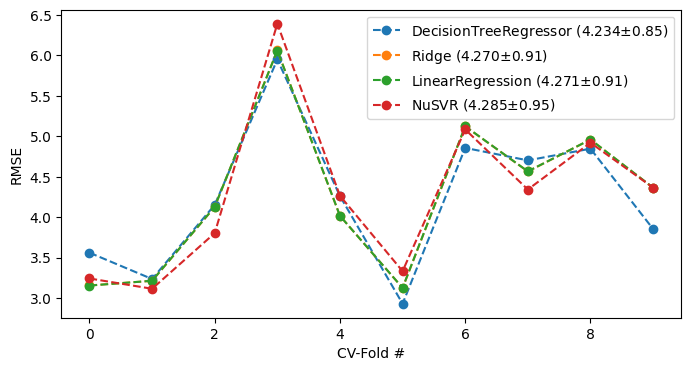

In [21]:
better_models = [tree.DecisionTreeRegressor(max_depth=1),
                 linear_model.Ridge(),
                 linear_model.LinearRegression(),
                 svm.NuSVR()]

fig, ax = plt.subplots(1, 1, figsize=(8,4))
for model in better_models:
    pipe = pipeline.make_pipeline(scaler, model)
    cv_results = skms.cross_val_score(pipe,
                                      student_ftrs, student_tgt,
                                      scoring = rms_scorer,
                                      cv=10)

    my_lbl = "{:s} ({:5.3f}$\pm${:.2f})".format(get_model_name(model),
                                                cv_results.mean(),
                                                cv_results.std())
    ax.plot(cv_results, 'o--', label=my_lbl)
    ax.set_xlabel('CV-Fold #')
    ax.set_ylabel("RMSE")
    ax.legend()